In [12]:
import numpy as np

X_train_feat = np.load("X_train.npy")
y_train      = np.load("y_train.npy")

X_val_feat   = np.load("X_val.npy")
y_val        = np.load("y_val.npy")

X_test_feat  = np.load("X_test.npy")
y_test       = np.load("y_test.npy")

print(X_train_feat.shape)

(53866, 40, 174, 1)


In [13]:
X_train_lstm = X_train_feat.reshape(X_train_feat.shape[0], 174, 40)
X_val_lstm   = X_val_feat.reshape(X_val_feat.shape[0], 174, 40)
X_test_lstm  = X_test_feat.reshape(X_test_feat.shape[0], 174, 40)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(174, 40)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(LSTM(32, return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(1, activation='sigmoid'))

model.summary()

D:\Jupyter\envs\deepfake_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 172, 64)             │           7,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 172, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 86, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 84, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 84, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 42, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,913 (214.50 KB)

 Trainable params: 54,529 (213.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    X_train_lstm,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    callbacks=[early_stop]
)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 93s 50ms/step - accuracy: 0.8944 - loss: 0.2659 - val_accuracy: 0.9543 - val_loss: 0.1254
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.9644 - loss: 0.1059 - val_accuracy: 0.9677 - val_loss: 0.1097
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9776 - loss: 0.0712 - val_accuracy: 0.9854 - val_loss: 0.0455
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 143s 49ms/step - accuracy: 0.9825 - loss: 0.0561 - val_accuracy: 0.9853 - val_loss: 0.0485
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9862 - loss: 0.0432 - val_accuracy: 0.9849 - val_loss: 0.0526


In [17]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
test_loss, test_acc = model.evaluate(X_test_lstm, y_test)

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9022 - loss: 0.2507


In [22]:
print("\n FINAL ACCURACY RESULTS:\n")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")


 FINAL ACCURACY RESULTS:

Train Accuracy      : 98.62%
Validation Accuracy : 98.49%
Test Accuracy       : 90.22%


In [19]:
model.save("cnn_lstm_deepfake_model.keras")

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Confusion Matrix:

[[2084  180]
 [ 273 2097]]


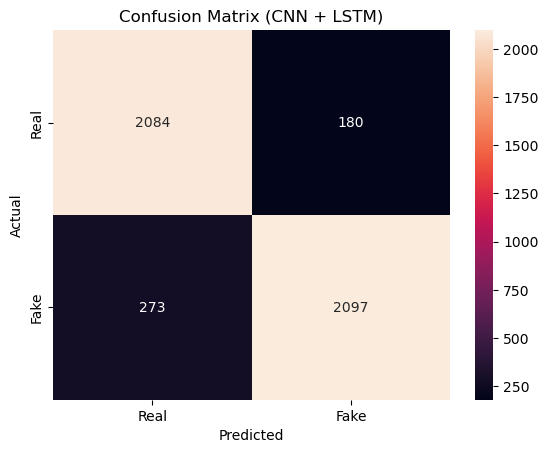


 Performance Metrics:

Accuracy  : 90.22%
Precision : 92.09%
Recall    : 88.48%
F1 Score  : 90.25%


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred_prob = model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)
plt.figure()

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (CNN + LSTM)")

plt.show()
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n Performance Metrics:\n")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")